# ABI Baseline — Converter vs MCI Classification

Adapts the Abnormality Index (ABI) from Stoecklein et al. (2020) to Schaefer 200-ROI
parcellated correlation matrices.
Uses a strict binary setup from `__v4__/metadata`: converters = `converter`, non-converters = `mci`.
The optimal ABI threshold is selected via Youden's J across 5-fold stratified CV.
Results are saved to a timestamped checkpoint directory for downstream consumption by `ABI_VS_GEC.ipynb`.

In [1]:
import json
import numpy as np
import os
import pandas as pd
import seaborn as sns
import warnings

from pathlib import Path
from matplotlib import pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from datetime import datetime

sns.set_theme(style='whitegrid')
warnings.filterwarnings('ignore', category=FutureWarning)

## Configuration

In [ ]:
WB_ROOT = Path('/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v3__/matrices')
METADATA_DIR = Path('/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v4__/metadata')
SPLITS_DIR = METADATA_DIR / 'splits_gec'
COHORTS_CSV = METADATA_DIR / 'cohorts.csv'

ABI_CHECKPOINT_DIR = Path('/mnt/e/fyassine/ad-early-detection/ABI/checkpoints/checkpoints_abi_whole_brain')
ABI_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

FILE_VARIANT = 'z_transformed'
FILE_SUFFIX = '_whole_brain_correlation_matrix_z_transformed.npz'

Z_THRESHOLD = 2.0
N_FOLDS = 5
RANDOM_STATE = 42

STD_FLOOR = 1e-6

print(f'Matrices root: {WB_ROOT}')
print(f'Splits dir: {SPLITS_DIR}')
print(f'Cohorts CSV: {COHORTS_CSV}')
print(f'ABI checkpoint dir: {ABI_CHECKPOINT_DIR}')
print(f'Z_THRESHOLD: {Z_THRESHOLD}')

Matrices root: /mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v3__/matrices
Splits dir: /mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v4__/metadata/splits_gec
Cohorts CSV: /mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v4__/metadata/cohorts.csv
ABI checkpoint dir: /mnt/e/fyassine/ad-early-detection/DCI/notebooks/checkpoints_abi_whole_brain
Z_THRESHOLD: 2.0


## Load Splits

In [3]:
allowed_diagnoses = {'converter', 'mci'}

cohorts_df = pd.read_csv(COHORTS_CSV)
id_candidates = ['Repseudonym', 'Pseudonym', 'ID']
cohort_id_col = next((c for c in id_candidates if c in cohorts_df.columns), None)
if cohort_id_col is None:
    raise ValueError(
        f"Missing subject ID column in cohorts CSV. Expected one of {id_candidates}, found: {list(cohorts_df.columns)}"
    )
if 'diagnosis' not in cohorts_df.columns:
    raise ValueError(f"Missing 'diagnosis' column in cohorts CSV: {COHORTS_CSV}")

cohorts_df[cohort_id_col] = cohorts_df[cohort_id_col].astype(str)
cohorts_df['diagnosis'] = cohorts_df['diagnosis'].astype(str).str.lower().str.strip()
cohort_diag_map = cohorts_df.groupby(cohort_id_col)['diagnosis'].apply(lambda s: set(s)).to_dict()

split_frames = {}
for name in ['train', 'val', 'test']:
    df = pd.read_csv(SPLITS_DIR / f'{name}.csv')
    df['Repseudonym'] = df['Repseudonym'].astype(str)
    if 'diagnosis' not in df.columns:
        raise ValueError(f"Missing 'diagnosis' column in split file: {name}.csv")

    df = df.copy()
    df['diagnosis'] = df['diagnosis'].astype(str).str.lower().str.strip()

    invalid_labels = sorted(set(df['diagnosis']) - allowed_diagnoses)
    if invalid_labels:
        raise ValueError(
            f"Split {name}.csv contains diagnoses outside {sorted(allowed_diagnoses)}: {invalid_labels}"
        )

    missing_in_cohorts = sorted(set(df['Repseudonym']) - set(cohort_diag_map.keys()))
    if missing_in_cohorts:
        raise ValueError(
            f"Split {name}.csv has IDs missing in cohorts.csv (first 10): {missing_in_cohorts[:10]}"
        )

    mismatched = [
        sid for sid, diag in zip(df['Repseudonym'], df['diagnosis'])
        if diag not in cohort_diag_map.get(sid, set())
    ]
    if mismatched:
        raise ValueError(
            f"Split {name}.csv has diagnosis not matched in cohorts.csv (first 10 IDs): {mismatched[:10]}"
        )

    df['converter_status'] = (df['diagnosis'] == 'converter').astype(int)
    split_frames[name] = df

for name, df in split_frames.items():
    counts = df['diagnosis'].value_counts().to_dict()
    n_subjects = int(df['Repseudonym'].nunique())
    if 'n_scans' in df.columns:
        total_scans_from_metadata = int(pd.to_numeric(df['n_scans'], errors='coerce').fillna(0).sum())
        print(
            f"{name}: subjects={n_subjects}, total_scans(metadata n_scans)={total_scans_from_metadata}, diagnosis_counts={counts}"
        )
    else:
        print(f"{name}: subjects={n_subjects}, diagnosis_counts={counts}")

train: subjects=86, total_scans(metadata n_scans)=177, diagnosis_counts={'converter': 43, 'mci': 43}
val: subjects=16, total_scans(metadata n_scans)=46, diagnosis_counts={'converter': 8, 'mci': 8}
test: subjects=14, total_scans(metadata n_scans)=31, diagnosis_counts={'mci': 7, 'converter': 7}


## Discover and Load Correlation Matrices

Replicates the file discovery logic from `ClassificationDataset`:
each subject may have multiple timepoint files (M0, M12, M24, ...).
All matching z-transformed whole-brain files for a subject are loaded.

In [4]:
all_npz_files = sorted([
    f for f in os.listdir(WB_ROOT)
    if f.endswith(FILE_SUFFIX) and f.startswith('sub-')
])

file_index = {}
for fname in all_npz_files:
    subject_id = fname.split('_')[0].replace('sub-', '')
    file_index.setdefault(subject_id, []).append(fname)

print(f'Total z-transformed files: {len(all_npz_files)}')
print(f'Unique subjects with files: {len(file_index)}')

Total z-transformed files: 1189
Unique subjects with files: 842


In [5]:
def load_matrix(filepath):
    data = np.load(filepath)
    key = 'array' if 'array' in data else list(data.keys())[0]
    return data[key].astype(np.float64)

def load_subject_matrices(subject_id):
    files = file_index.get(subject_id, [])
    matrices = []
    for fname in files:
        mat = load_matrix(WB_ROOT / fname)
        matrices.append(mat)
    return matrices

sample_mat = load_matrix(WB_ROOT / all_npz_files[0])
N_ROIS = sample_mat.shape[0]
print(f'Matrix shape: {sample_mat.shape}')
print(f'Number of ROIs: {N_ROIS}')

Matrix shape: (200, 200)
Number of ROIs: 200


In [6]:
all_subjects_df = pd.concat(split_frames.values(), ignore_index=True)
all_subjects_df = all_subjects_df.drop_duplicates(subset=['Repseudonym'], keep='first')

subject_data = []
missing_subjects = []

for _, row in all_subjects_df.iterrows():
    sid = str(row['Repseudonym'])
    matrices = load_subject_matrices(sid)
    if not matrices:
        missing_subjects.append(sid)
        continue
    for mat in matrices:
        subject_data.append({
            'subject_id': sid,
            'diagnosis': row['diagnosis'],
            'converter_status': int(row['converter_status']),
            'sex': row['sex'],
            'age': float(row['age']),
            'matrix': mat,
        })

loaded_counts_df = pd.DataFrame([
    {'subject_id': e['subject_id'], 'diagnosis': e['diagnosis'], 'converter_status': e['converter_status']}
    for e in subject_data
])

n_subjects_in_splits = int(all_subjects_df['Repseudonym'].nunique())
n_subjects_with_scans = int(loaded_counts_df['subject_id'].nunique()) if not loaded_counts_df.empty else 0
print(
    f'Loaded scan samples: {len(subject_data)} from {n_subjects_with_scans} subjects '
    f'(subjects listed in splits: {n_subjects_in_splits})'
)

if not loaded_counts_df.empty:
    diagnosis_breakdown = (
        loaded_counts_df
        .groupby('diagnosis')
        .agg(subjects=('subject_id', 'nunique'), scans=('subject_id', 'size'))
        .sort_index()
    )
    print('\nLoaded diagnosis breakdown (subjects vs scans):')
    print(diagnosis_breakdown.to_string())

if missing_subjects:
    print(f'Warning: {len(missing_subjects)} subjects had no matching matrix files')

Loaded scan samples: 364 from 116 subjects (subjects listed in splits: 116)

Loaded diagnosis breakdown (subjects vs scans):
           subjects  scans
diagnosis                 
converter        58    196
mci              58    168


## Build Reference from Training MCI Subjects

Element-wise mean and standard deviation of correlation matrices from training-split
MCI subjects only (non-converters in this strict binary setup). This serves as the
reference distribution for ABI z-score abnormality computation.

In [7]:
train_ids = set(split_frames['train']['Repseudonym'].astype(str))
reference_train_ids = set(
    split_frames['train'].loc[
        split_frames['train']['diagnosis'].str.lower().str.strip() == 'mci',
        'Repseudonym'
    ].astype(str)
)

if len(reference_train_ids) == 0:
    raise RuntimeError('No MCI subjects found in training split to build ABI reference.')

reference_matrices = []
for sid in reference_train_ids:
    for mat in load_subject_matrices(sid):
        reference_matrices.append(mat)

if len(reference_matrices) == 0:
    raise RuntimeError('No matrices found for training MCI subjects while building ABI reference.')

reference_stack = np.stack(reference_matrices, axis=0)
ref_mean = np.mean(reference_stack, axis=0)
ref_std = np.std(reference_stack, axis=0, ddof=1)

np.fill_diagonal(ref_mean, 0.0)
np.fill_diagonal(ref_std, 1.0)
ref_std = np.clip(ref_std, STD_FLOOR, None)

print(f'Reference built from {len(reference_matrices)} matrices ({len(reference_train_ids)} MCI subjects)')
print(f'ref_mean range: [{ref_mean.min():.4f}, {ref_mean.max():.4f}]')
print(f'ref_std range: [{ref_std.min():.6f}, {ref_std.max():.4f}]')
print(f'Symmetric check (mean): {np.allclose(ref_mean, ref_mean.T)}')
print(f'Symmetric check (std): {np.allclose(ref_std, ref_std.T)}')

Reference built from 120 matrices (43 MCI subjects)
ref_mean range: [-0.3473, 1.0337]
ref_std range: [0.143587, 1.0000]
Symmetric check (mean): True
Symmetric check (std): True


## Compute ABI for All Subjects

For each sample's 200×200 correlation matrix:
1. Z-score each connection: `ABS_ij = (F_ij - MEAN_ij) / STD_ij`
2. Threshold: count connections where `|ABS_ij| > Z_THRESHOLD`
3. Abnormality Count (ABC) per ROI: `ABC_i = sum(|ABS_ij| > z, j ≠ i)`
4. ABI = `mean(ABC)` across all ROIs

**Z-threshold rationale**: The original Stoecklein et al. threshold of 4.0 is very conservative for parcellated correlation matrices (200 ROIs), causing most connections to never be flagged as abnormal. ABI scores therefore cluster near zero for both converters and non-converters, making the signal indistinguishable from noise. Using `Z_THRESHOLD = 2.0` captures more subtle but consistent connectivity deviations, producing richer variability in ABI scores and more discriminative power between groups.

In [8]:
def compute_abi(matrix, ref_mean, ref_std, z_threshold=4.0):
    abs_score = (matrix - ref_mean) / ref_std
    abs_score = np.nan_to_num(abs_score, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(abs_score, 0.0)
    abnormal = (np.abs(abs_score) > z_threshold).astype(np.float64)
    abc_per_roi = np.sum(abnormal, axis=1)
    abi = np.mean(abc_per_roi)
    return abi

for entry in subject_data:
    entry['abi'] = compute_abi(entry['matrix'], ref_mean, ref_std, Z_THRESHOLD)

abi_df = pd.DataFrame([{
    'subject_id': e['subject_id'],
    'diagnosis': e['diagnosis'],
    'converter_status': e['converter_status'],
    'sex': e['sex'],
    'age': e['age'],
    'abi': e['abi'],
} for e in subject_data])

print(f'ABI computed for {len(abi_df)} samples')
print(f'\nABI statistics by converter status:')
print(abi_df.groupby('converter_status')['abi'].describe())

ABI computed for 364 samples

ABI statistics by converter status:
                  count      mean       std   min   25%    50%      75%    max
converter_status                                                              
0                 168.0  8.976369  6.560713  2.34  5.10  7.340  11.1525  61.46
1                 196.0  8.261582  4.393212  2.50  5.62  7.345   9.5625  43.58


/tmp/ipykernel_1059474/1005268790.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Converter', 'Converter'])


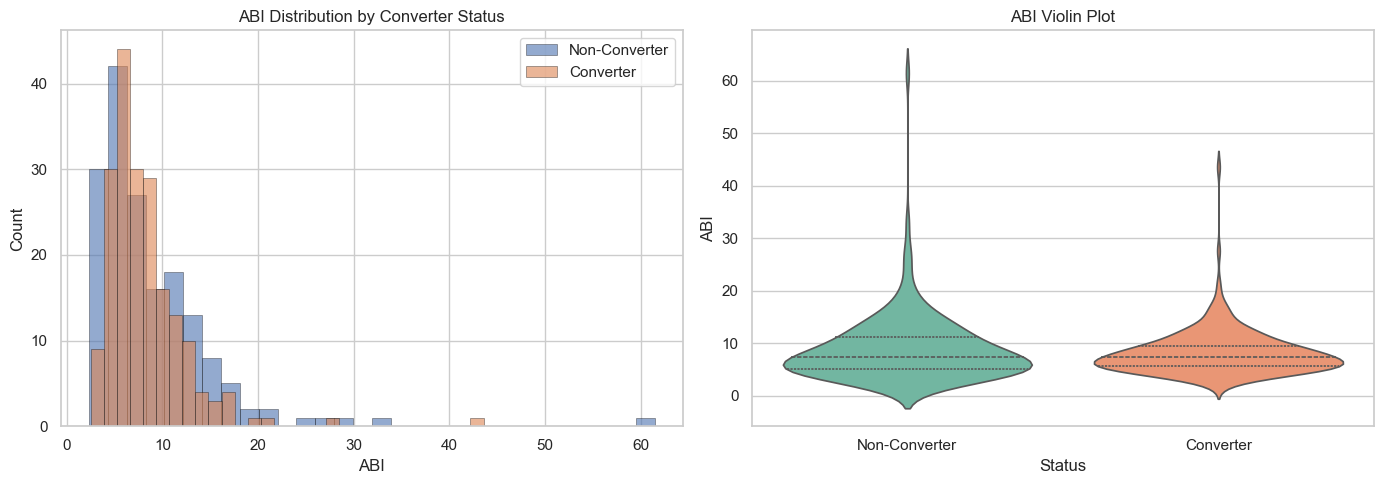

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, group in abi_df.groupby('converter_status'):
    tag = 'Converter' if label == 1 else 'Non-Converter'
    axes[0].hist(group['abi'], bins=30, alpha=0.6, label=tag, edgecolor='black', linewidth=0.4)
axes[0].set_xlabel('ABI')
axes[0].set_ylabel('Count')
axes[0].set_title('ABI Distribution by Converter Status')
axes[0].legend()

sns.violinplot(
    data=abi_df,
    x='converter_status',
    y='abi',
    ax=axes[1],
    inner='quartile',
    palette='Set2',
)
axes[1].set_xticklabels(['Non-Converter', 'Converter'])
axes[1].set_xlabel('Status')
axes[1].set_ylabel('ABI')
axes[1].set_title('ABI Violin Plot')

plt.tight_layout()
plt.savefig(ABI_CHECKPOINT_DIR / 'abi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Assign Samples to Splits (Matching GEC)

Map each sample to its split using subject IDs. The CV pool = train + val,
holdout = test. Multiple timepoints per subject are included (matching `ClassificationDataset`).

In [10]:
val_ids = set(split_frames['val']['Repseudonym'].astype(str))
test_ids = set(split_frames['test']['Repseudonym'].astype(str))

def get_split(sid):
    if sid in test_ids:
        return 'test'
    elif sid in val_ids:
        return 'val'
    elif sid in train_ids:
        return 'train'
    return 'unknown'

abi_df['split'] = abi_df['subject_id'].apply(get_split)

cv_df = abi_df[abi_df['split'].isin(['train', 'val'])].reset_index(drop=True)
holdout_df = abi_df[abi_df['split'] == 'test'].reset_index(drop=True)

cv_subjects = int(cv_df['subject_id'].nunique())
holdout_subjects = int(holdout_df['subject_id'].nunique())
cv_converter_scans = int(cv_df['converter_status'].sum())
holdout_converter_scans = int(holdout_df['converter_status'].sum())
cv_converter_subjects = int(cv_df.loc[cv_df['converter_status'] == 1, 'subject_id'].nunique())
holdout_converter_subjects = int(holdout_df.loc[holdout_df['converter_status'] == 1, 'subject_id'].nunique())

print(
    f'CV pool: scans={len(cv_df)}, subjects={cv_subjects}, '
    f'converter_scans={cv_converter_scans}, converter_subjects={cv_converter_subjects}'
)
print(
    f'Holdout: scans={len(holdout_df)}, subjects={holdout_subjects}, '
    f'converter_scans={holdout_converter_scans}, converter_subjects={holdout_converter_subjects}'
)

CV pool: scans=322, subjects=102, converter_scans=172, converter_subjects=51
Holdout: scans=42, subjects=14, converter_scans=24, converter_subjects=7


## 5-Fold Stratified Cross-Validation

The optimal ABI threshold is selected per fold via Youden's J statistic on the ROC curve.
The median threshold across folds is used as the final holdout threshold.

In [11]:
cv_labels = cv_df['converter_status'].values
cv_abi = cv_df['abi'].values

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_results = {
    'fold': [], 'val_auc': [], 'val_sensitivity': [],
    'val_specificity': [], 'val_f1': [], 'best_threshold': [],
}

print(f'Starting {N_FOLDS}-fold stratified cross-validation...')
print('=' * 60)

for fold, (train_idx, val_idx) in enumerate(skf.split(cv_abi, cv_labels)):
    print(f'\nFOLD {fold + 1}/{N_FOLDS}')
    print('-' * 40)

    y_train, y_val = cv_labels[train_idx], cv_labels[val_idx]
    abi_train, abi_val = cv_abi[train_idx], cv_abi[val_idx]

    fold_train_df = cv_df.iloc[train_idx]
    fold_val_df = cv_df.iloc[val_idx]
    train_subjects = int(fold_train_df['subject_id'].nunique())
    val_subjects = int(fold_val_df['subject_id'].nunique())
    train_converter_subjects = int(fold_train_df.loc[fold_train_df['converter_status'] == 1, 'subject_id'].nunique())
    val_converter_subjects = int(fold_val_df.loc[fold_val_df['converter_status'] == 1, 'subject_id'].nunique())

    print(
        f'  Train: scans={len(train_idx)}, subjects={train_subjects}, '
        f'converter_scans={int(y_train.sum())}, converter_subjects={train_converter_subjects}'
    )
    print(
        f'  Val:   scans={len(val_idx)}, subjects={val_subjects}, '
        f'converter_scans={int(y_val.sum())}, converter_subjects={val_converter_subjects}'
    )

    fpr_t, tpr_t, thresholds_t = roc_curve(y_val, abi_val)
    auc_t = auc(fpr_t, tpr_t)
    j_scores = tpr_t - fpr_t
    best_idx = np.argmax(j_scores)
    best_thr = thresholds_t[best_idx]

    preds_t = (abi_val >= best_thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds_t, labels=[0, 1]).ravel()
    sens_t = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec_t = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1_t = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0

    cv_results['fold'].append(fold + 1)
    cv_results['val_auc'].append(auc_t)
    cv_results['val_sensitivity'].append(sens_t)
    cv_results['val_specificity'].append(spec_t)
    cv_results['val_f1'].append(f1_t)
    cv_results['best_threshold'].append(float(best_thr))

    print(f'  AUC={auc_t:.4f}, Sens={sens_t:.4f}, Spec={spec_t:.4f}, F1={f1_t:.4f}, Thr={best_thr:.4f}')

print('\n' + '=' * 60)
print('CROSS-VALIDATION COMPLETE')

Starting 5-fold stratified cross-validation...

FOLD 1/5
----------------------------------------
  Train: scans=257, subjects=94, converter_scans=137, converter_subjects=49
  Val:   scans=65, subjects=48, converter_scans=35, converter_subjects=25
  AUC=0.5943, Sens=0.9429, Spec=0.3667, F1=0.7586, Thr=4.6500

FOLD 2/5
----------------------------------------
  Train: scans=257, subjects=98, converter_scans=137, converter_subjects=50
  Val:   scans=65, subjects=50, converter_scans=35, converter_subjects=26
  AUC=0.3595, Sens=0.9429, Spec=0.1667, F1=0.7097, Thr=4.3100

FOLD 3/5
----------------------------------------
  Train: scans=258, subjects=96, converter_scans=138, converter_subjects=47
  Val:   scans=64, subjects=46, converter_scans=34, converter_subjects=24
  AUC=0.4451, Sens=1.0000, Spec=0.0333, F1=0.7010, Thr=3.6300

FOLD 4/5
----------------------------------------
  Train: scans=258, subjects=100, converter_scans=138, converter_subjects=50
  Val:   scans=64, subjects=48, conv

## Cross-Validation Results Summary

In [12]:
print('ABI Threshold — CV Summary:')
print('=' * 60)
print(f'{"Metric":<20} {"Mean":>10} {"Std":>10} {"Min":>10} {"Max":>10}')
print('-' * 60)
for metric in ['val_auc', 'val_sensitivity', 'val_specificity', 'val_f1']:
    vals = np.array(cv_results[metric])
    print(f'{metric:<20} {vals.mean():>10.4f} {vals.std():>10.4f} {vals.min():>10.4f} {vals.max():>10.4f}')

best_threshold = float(np.median(cv_results['best_threshold']))
print(f'\nMedian CV threshold (for holdout): {best_threshold:.4f}')
print(f'Per-fold thresholds: {[f"{t:.4f}" for t in cv_results["best_threshold"]]}')

ABI Threshold — CV Summary:
Metric                     Mean        Std        Min        Max
------------------------------------------------------------
val_auc                  0.5137     0.1178     0.3595     0.6951
val_sensitivity          0.8713     0.1189     0.6765     1.0000
val_specificity          0.3200     0.1996     0.0333     0.6000
val_f1                   0.7061     0.0470     0.6216     0.7586

Median CV threshold (for holdout): 4.6500
Per-fold thresholds: ['4.6500', '4.3100', '3.6300', '6.3600', '6.0500']


## Save ABI Results to Checkpoint Directory

Saves a timestamped run directory under `checkpoints_abi_whole_brain/` containing:
- `abi_values.csv` — per-sample ABI scores with split assignments
- `run_summary.json` — CV results, config, and the median threshold for holdout use

In [13]:
run_timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
run_name = f'abi_run_{run_timestamp}'
run_dir = ABI_CHECKPOINT_DIR / run_name
run_dir.mkdir(parents=True, exist_ok=True)

abi_df.to_csv(run_dir / 'abi_values.csv', index=False)

cv_summary = {
    'auc_mean': float(np.mean(cv_results['val_auc'])),
    'auc_std': float(np.std(cv_results['val_auc'])),
    'sensitivity_mean': float(np.mean(cv_results['val_sensitivity'])),
    'specificity_mean': float(np.mean(cv_results['val_specificity'])),
    'f1_mean': float(np.mean(cv_results['val_f1'])),
}

run_summary = {
    'run_name': run_name,
    'run_timestamp': run_timestamp,
    'z_threshold': Z_THRESHOLD,
    'n_folds': N_FOLDS,
    'random_state': RANDOM_STATE,
    'n_rois': int(N_ROIS),
    'reference_group': 'mci_train',
    'n_reference_matrices': len(reference_matrices),
    'n_reference_subjects': len(reference_train_ids),
    'best_threshold': best_threshold,
    'cv_results': cv_results,
    'cv_summary': cv_summary,
}

with open(run_dir / 'run_summary.json', 'w') as f:
    json.dump(run_summary, f, indent=2)

print(f'Saved to: {run_dir}')
for p in sorted(run_dir.iterdir()):
    print(f'  {p.name}')

Saved to: /mnt/e/fyassine/ad-early-detection/DCI/notebooks/checkpoints_abi_whole_brain/abi_run_2026-05-08_10-33-29
  abi_values.csv
  run_summary.json


## Holdout Test-Set Evaluation

Evaluates the median CV threshold (from `run_summary.json`) on the held-out test set.

In [14]:
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

holdout_labels  = holdout_df['converter_status'].values
holdout_abi     = holdout_df['abi'].values

holdout_auc  = roc_auc_score(holdout_labels, holdout_abi) if len(set(holdout_labels)) > 1 else 0.0
holdout_pred = (holdout_abi >= best_threshold).astype(int)
cm_h = confusion_matrix(holdout_labels, holdout_pred, labels=[0,1])
tn,fp,fn,tp = cm_h.ravel() if cm_h.size == 4 else (0,0,0,0)
holdout_sens = tp / (tp + fn + 1e-9)
holdout_spec = tn / (tn + fp + 1e-9)
holdout_f1   = f1_score(holdout_labels, holdout_pred, zero_division=0)

print(f'Holdout AUC={holdout_auc:.4f}  Sens={holdout_sens:.4f}  Spec={holdout_spec:.4f}  F1={holdout_f1:.4f}')

# Back-patch most recent run_summary.json
import glob
runs = sorted(glob.glob(str(ABI_CHECKPOINT_DIR / '*/run_summary.json')))
if runs:
    with open(runs[-1]) as _f: _s = json.load(_f)
    _s.update({
        'test_auc':          float(holdout_auc),
        'test_sensitivity':  float(holdout_sens),
        'test_specificity':  float(holdout_spec),
        'test_f1':           float(holdout_f1),
        'test_probabilities': holdout_abi.tolist(),
        'test_labels':        holdout_labels.tolist(),
    })
    with open(runs[-1], 'w') as _f: json.dump(_s, _f, indent=2)
    print(f'Test metrics saved to {runs[-1]}')


Holdout AUC=0.4178  Sens=0.9167  Spec=0.1667  F1=0.7213
Test metrics saved to /mnt/e/fyassine/ad-early-detection/DCI/notebooks/checkpoints_abi_whole_brain/abi_run_2026-05-08_10-33-29/run_summary.json
